# Notebook 3: Attention-Analyse
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Attention-Muster visualisieren und wichtige Heads identifizieren.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - HuggingFace `output_attentions`: https://huggingface.co/docs/transformers/main_classes/output
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
> - NumPy argsort: https://numpy.org/doc/stable/reference/generated/numpy.argsort.html

## Hintergrund: Attention-Mechanismus

In jedem Transformer-Layer berechnen **Attention Heads** gewichtete Summen über alle Token-Positionen:

```
A = softmax( QK^T / sqrt(d_head) )
```

Die Attention-Matrix A hat die Form **(seq × seq)**:
- Zeile i: Welche Positionen achtet Position i?
- Spalte j: Von welchen Positionen wird Position j beachtet?

In der Mechanistic Interpretability fragen wir: **Welche Heads implementieren welche Funktion?**

Bekannte Head-Typen:
- **Previous Token Heads**: Achten auf das unmittelbar vorherige Token
- **Induction Heads**: Implementieren Muster-Vervollständigung ("A...B...A → B")
- **Name Mover Heads**: Transportieren semantische Information zur Ausgabe-Position

## 1. Setup und Modell laden

In [1]:
# TODO: Importiere torch, numpy, matplotlib
# TODO: Lade Tokenizer und Modell (wie in Notebook 1)
#
# MODEL_NAME = "EleutherAI/pythia-410m"
# n_layers = model.config.num_hidden_layers
# n_heads  = model.config.num_attention_heads
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
MODEL_NAME = "EleutherAI/pythia-410m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tokenizer laden
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Modell laden
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",   # wichtig für Attention-Ausgabe
    torch_dtype=torch.float32
)

# Auf Gerät verschieben
model = model.to(device)

# Eval-Modus
model.eval()

print("Modell geladen!")
print("Device:", device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Modell geladen!
Device: cuda


## 2. Forward Pass mit Attention-Gewichten

In [2]:
prompt =  "The movie was good. The sentiment is"

# TODO: Tokenisiere den Prompt und konvertiere zu Token-Strings
# TODO: Führe einen Forward Pass mit output_attentions=True durch
#
#   outputs = model(**inputs, output_attentions=True)
#
# TODO: Analysiere outputs.attentions:
#   - Wie viele Attention-Matrizen gibt es?
#   - Was ist die Shape jeder Matrix? (Tipp: batch, heads, seq, seq)
#
# Hinweis: outputs.attentions ist ein Tupel der Länge n_layers



# Tokenisieren
inputs = tokenizer(prompt, return_tensors="pt").to(device)

# Token-IDs → Token-Strings
tokens = [tokenizer.decode([t]) for t in inputs["input_ids"][0]]

print("Tokens:")
for i, tok in enumerate(tokens):
    print(i, repr(tok))

# Forward Pass mit Attentions
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# Attention-Matrizen
attentions = outputs.attentions

print("\nAnzahl Attention-Matrizen:", len(attentions))

print("\nShapes:")
for layer_idx, attn in enumerate(attentions):
    print(f"Layer {layer_idx}: {attn.shape}")

Tokens:
0 'The'
1 ' movie'
2 ' was'
3 ' good'
4 '.'
5 ' The'
6 ' sentiment'
7 ' is'

Anzahl Attention-Matrizen: 24

Shapes:
Layer 0: torch.Size([1, 16, 8, 8])
Layer 1: torch.Size([1, 16, 8, 8])
Layer 2: torch.Size([1, 16, 8, 8])
Layer 3: torch.Size([1, 16, 8, 8])
Layer 4: torch.Size([1, 16, 8, 8])
Layer 5: torch.Size([1, 16, 8, 8])
Layer 6: torch.Size([1, 16, 8, 8])
Layer 7: torch.Size([1, 16, 8, 8])
Layer 8: torch.Size([1, 16, 8, 8])
Layer 9: torch.Size([1, 16, 8, 8])
Layer 10: torch.Size([1, 16, 8, 8])
Layer 11: torch.Size([1, 16, 8, 8])
Layer 12: torch.Size([1, 16, 8, 8])
Layer 13: torch.Size([1, 16, 8, 8])
Layer 14: torch.Size([1, 16, 8, 8])
Layer 15: torch.Size([1, 16, 8, 8])
Layer 16: torch.Size([1, 16, 8, 8])
Layer 17: torch.Size([1, 16, 8, 8])
Layer 18: torch.Size([1, 16, 8, 8])
Layer 19: torch.Size([1, 16, 8, 8])
Layer 20: torch.Size([1, 16, 8, 8])
Layer 21: torch.Size([1, 16, 8, 8])
Layer 22: torch.Size([1, 16, 8, 8])
Layer 23: torch.Size([1, 16, 8, 8])


## 3. Einzelne Attention-Heads visualisieren

In [3]:
# TODO: Implementiere plot_attention_head(attentions, layer, head, tokens):
#   1. Extrahiere die Attention-Matrix: attentions[layer][0, head]
#   2. Konvertiere zu NumPy: .cpu().numpy()
#   3. Erstelle Heatmap mit plt.imshow(..., cmap="Blues")
#   4. Setze Token-Labels auf X- und Y-Achse
#   5. Beschrifte Achsen ("Key (Quelle)" / "Query (Ziel)")
#
# TODO: Visualisiere 6 verschiedene Heads in einem 2×3-Grid (plt.subplots(2, 3))
#   Wähle unterschiedliche Schichten (z.B. 0, 5, 10, 15, 20, 23) und Heads
#
# Dokumentation plt.subplots:
#   https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

def plot_attention_head(attentions, layer, head, tokens, ax=None):
    # 1. Attention-Matrix extrahieren
    attn_matrix = attentions[layer][0, head]

    # 2. Zu NumPy konvertieren
    attn_matrix = attn_matrix.detach().cpu().numpy()

    # 3. Plot-Achse vorbereiten
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(attn_matrix, cmap="Blues", aspect="auto")

    # 4. Token-Labels
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))

    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)

    # 5. Achsen beschriften
    ax.set_xlabel("Key (Quelle)")
    ax.set_ylabel("Query (Ziel)")

    ax.set_title(f"Layer {layer}, Head {head}")

    return im

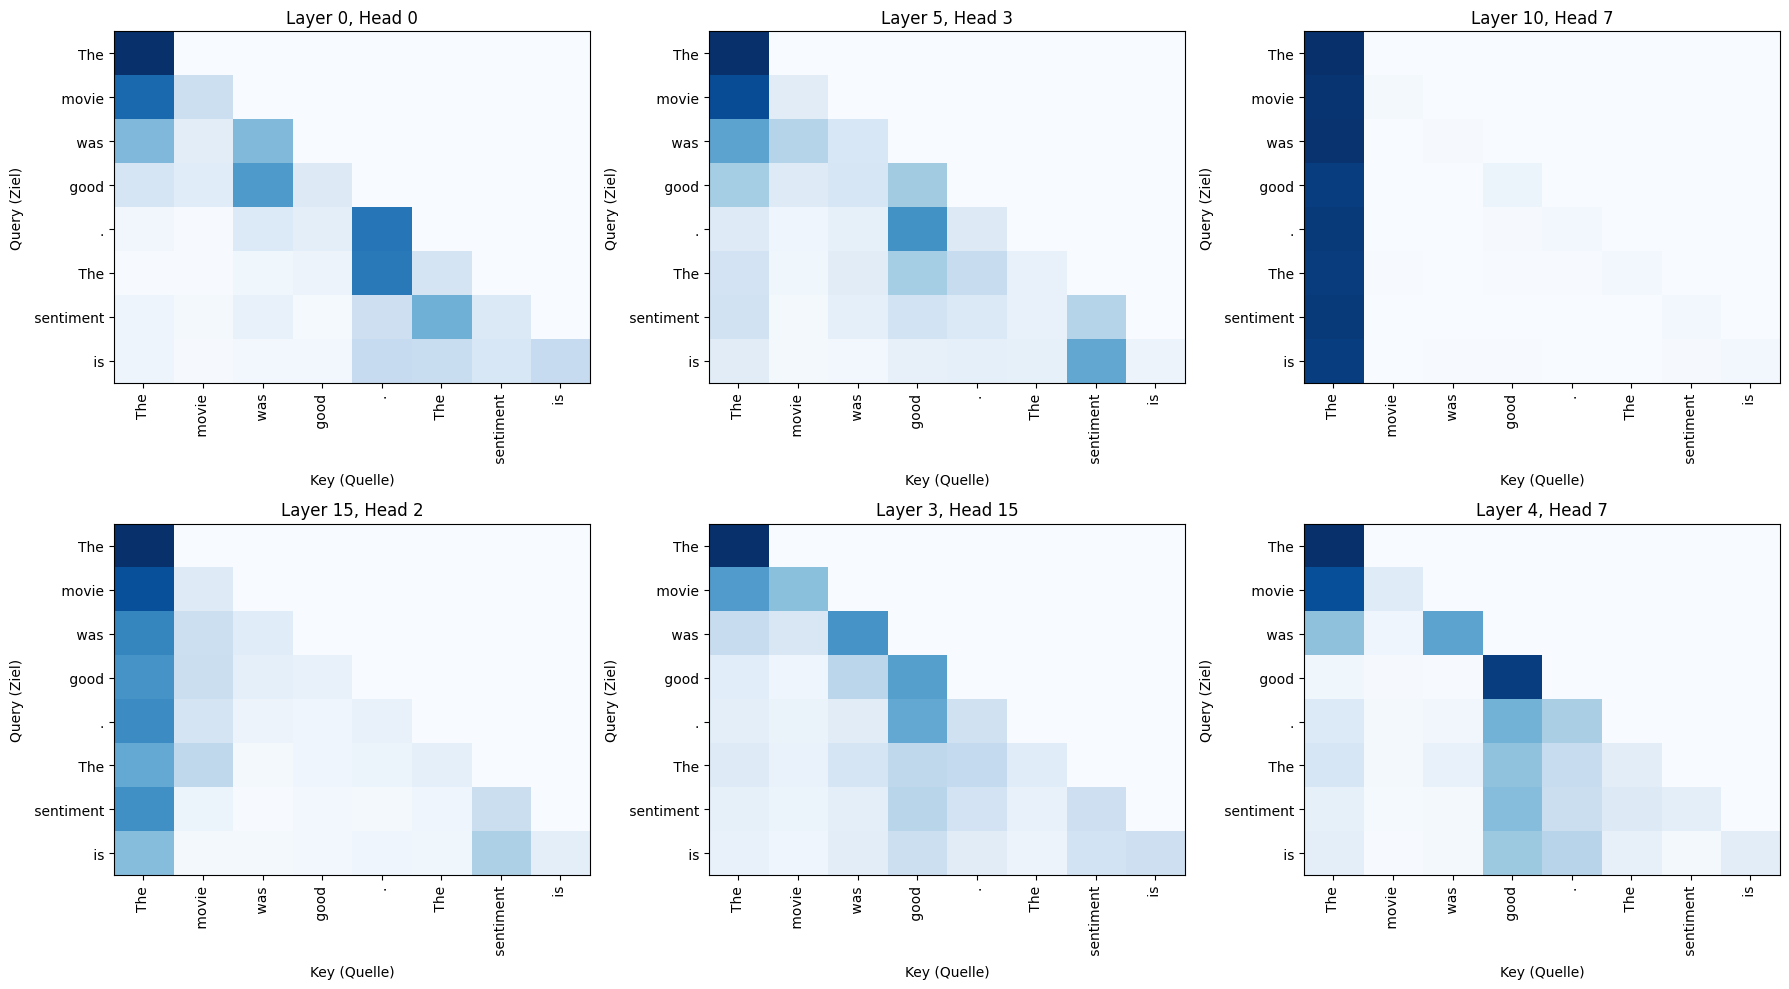

In [4]:
heads_to_plot = [
    (0, 0),
    (5, 3),
    (10, 7),
    (15, 2),
    (3, 15),
    (4, 7),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (layer, head) in zip(axes.flatten(), heads_to_plot):
    plot_attention_head(attentions, layer, head, tokens, ax=ax)

plt.tight_layout()
plt.show()

## 4. Attention auf Subject-Token

Subject positions: [3]
subject_pos: 3 → ' good'
last_pos: 7 → ' is'
att_to_subject shape: (24, 16)


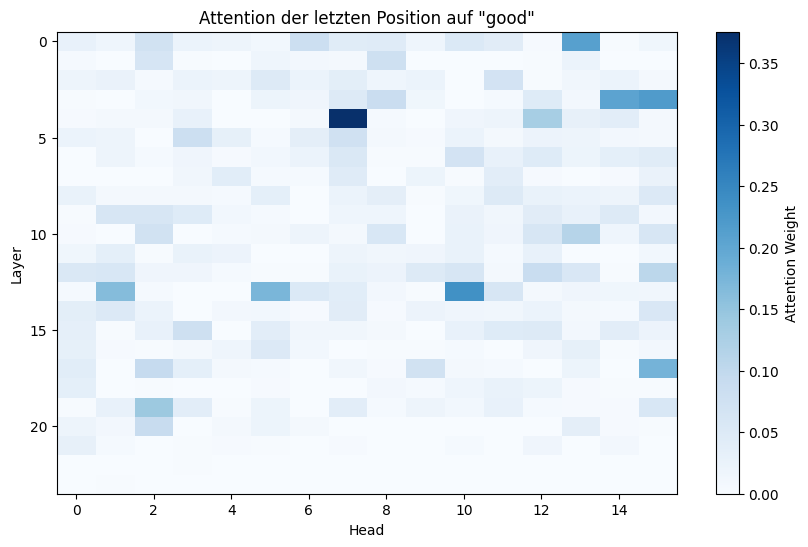

In [5]:
# Ziel: Wie stark achtet die LETZTE Position auf das Subject-Token "France"?
# Dies gibt einen Hinweis auf "Faktenwissen-Abruf"-Heads.
#
# TODO: Finde die Position des Tokens "France" in der Token-Liste
#   Tipp: tokens.index(subject_token) oder verwende eine List-Comprehension
#
# TODO: Berechne für ALLE Layers und Heads:
#   att_to_subject[layer, head] = attentions[layer][0, head, last_pos, subject_pos]
#   Ergebnis: Matrix der Form (n_layers, n_heads)
#
# Tipp: Zwei verschachtelte for-Schleifen (layer, head)
# Hinweis: np.zeros((n_layers, n_heads)) erstellt eine Nullmatrix
subject_token = " good"

subject_positions = [i for i, tok in enumerate(tokens) if tok == subject_token]

print("Subject positions:", subject_positions)

subject_pos = subject_positions[0]
last_pos = len(tokens) - 1

print("subject_pos:", subject_pos, "→", repr(tokens[subject_pos]))
print("last_pos:", last_pos, "→", repr(tokens[last_pos]))

n_layers = len(attentions)
n_heads = attentions[0].shape[1]

att_to_subject = np.zeros((n_layers, n_heads))

for layer in range(n_layers):
    for head in range(n_heads):
        att_value = attentions[layer][0, head, last_pos, subject_pos]
        att_to_subject[layer, head] = att_value.detach().cpu().item()

print("att_to_subject shape:", att_to_subject.shape)


plt.figure(figsize=(10, 6))

plt.imshow(att_to_subject, cmap="Blues", aspect="auto")

plt.xlabel("Head")
plt.ylabel("Layer")
plt.title('Attention der letzten Position auf "good"')

plt.colorbar(label="Attention Weight")

plt.show()

## 5. Heatmap: Alle Heads und Layers

In [ ]:
# TODO: Erstelle eine Heatmap mit plt.imshow() für die att_to_subject-Matrix:
#   - Y-Achse: Schichten
#   - X-Achse: Heads
#   - Farbe: Attention-Gewicht (cmap="hot" oder "Blues")
#   - Colorbar hinzufügen: plt.colorbar(im, ...)
#
# TODO: Markiere die Top-5 Heads mit einem Rechteck (plt.Rectangle)
#   Tipp: np.argsort(att_to_subject.ravel())[-5:] gibt die 5 höchsten Indizes
#   Tipp: np.unravel_index(idx, (n_layers, n_heads)) konvertiert flachen Index
#
# Dokumentation plt.Rectangle:
#   https://matplotlib.org/stable/api/patches_api.html#matplotlib.patches.Rectangle

## 6. Top-Heads-Rangliste

In [ ]:
# TODO: Erstelle eine Rangliste der Top-10 Heads nach att_to_subject-Wert
#   Ausgabe: Rang | Layer | Head | Attention-Gewicht
#
# Tipp: np.argsort(att_to_subject.ravel())[::-1] sortiert absteigend
# Tipp: divmod(flat_idx, n_heads) gibt (layer, head) zurück

## 7. BONUS: Induction Heads suchen

In [ ]:
# BONUS-AUFGABE: Induction Heads erkennt man an einem charakteristischen Muster:
#   Sie achten bei Token i auf Token (i-2) oder folgen einem "A...B...A → B"-Muster.
#
# TODO: Implementiere eine induction_score(att_matrix) Funktion:
#   Misst, wie stark eine Attention-Matrix auf die um 1-2 Positionen versetzte
#   Diagonale konzentriert ist.
#
# TODO: Berechne den Score für alle Layers/Heads und erstelle eine Heatmap.
# TODO: Welcher Head hat den höchsten Induction Score?
#
# Weiterführende Lektüre:
#   Olsson et al. (2022): "In-context Learning and Induction Heads"
#   https://arxiv.org/abs/2209.11895

## 8. Reflexionsfragen

In [ ]:
# Beantworte folgende Fragen:
#
# 1. Welcher Head (Layer, Head-Nummer) achtet am stärksten auf "France"?
# 2. In welchen Schichten-Bereichen findest du die stärkste Subject-Attention?
# 3. Warum reicht Attention-Analyse allein NICHT aus, um Kausalität zu zeigen?
# 4. Was ist der Unterschied zwischen Attention-Analyse und Activation Patching?
#
# Denke daran: Hohe Attention ≠ kausale Wichtigkeit\!
# (Das behandeln wir in Notebook 5 mit Activation Patching)